In [1]:
import micropip
await micropip.install('seaborn')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

%matplotlib inline

df = pd.read_csv("loan_data.csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [3]:
print("Колонки датасету:")
print(df.columns)

print("\nРозмір датасету (рядки, колонки):")
print(df.shape)


Колонки датасету:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Розмір датасету (рядки, колонки):
(381, 13)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 26.9+ KB


In [5]:
df.isnull().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
df_clean = df.copy()
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
print(df_clean.isnull().sum())


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [9]:
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
df_clean.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
1,1,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
2,2,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
3,3,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
4,4,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1


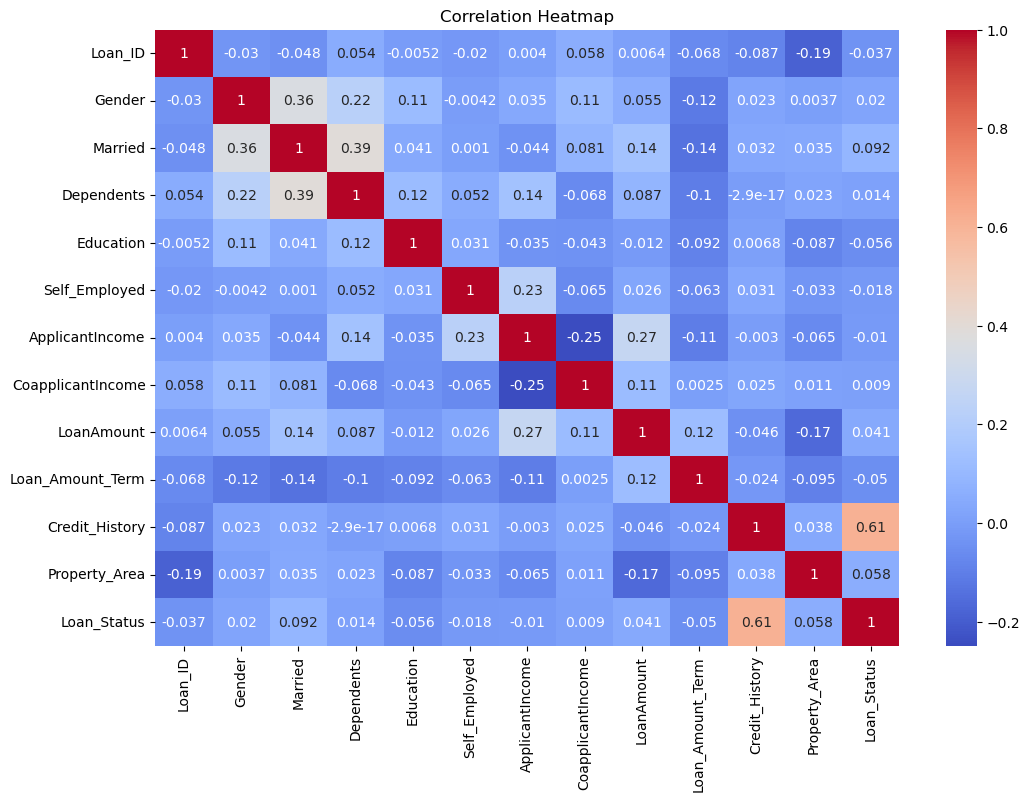

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


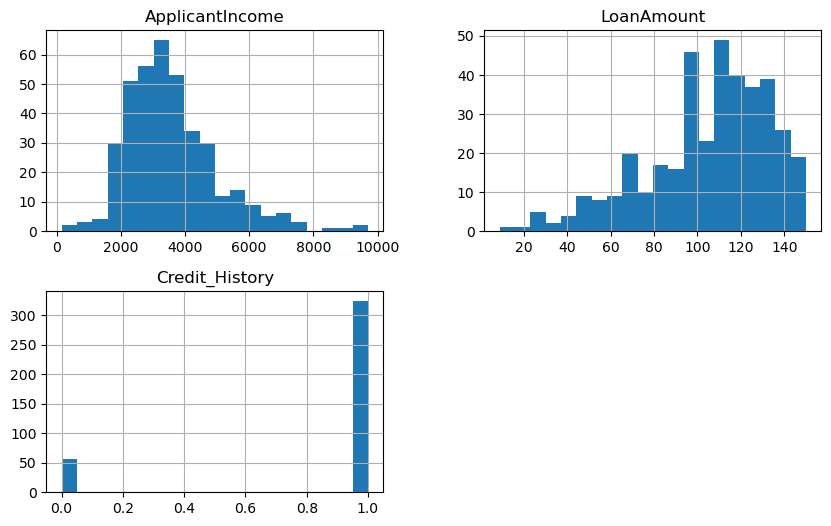

In [11]:
df_clean[['ApplicantIncome', 'LoanAmount', 'Credit_History']].hist(
    figsize=(10, 6),
    bins=20
)
plt.show()


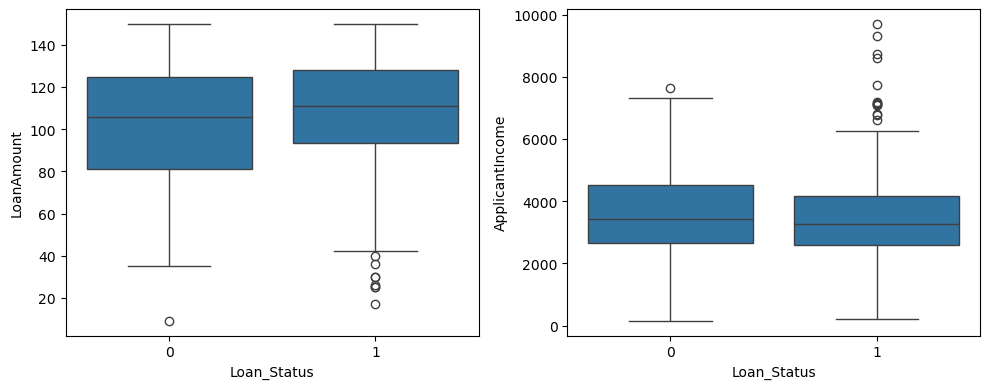

In [12]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df_clean)
plt.subplot(1, 2, 2)
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df_clean)
plt.tight_layout()
plt.show()


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(X_train.shape, X_test.shape)


(285, 12) (96, 12)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



[[11 18]
 [ 0 67]]
              precision    recall  f1-score   support

           0       1.00      0.38      0.55        29
           1       0.79      1.00      0.88        67

    accuracy                           0.81        96
   macro avg       0.89      0.69      0.72        96
weighted avg       0.85      0.81      0.78        96



In [16]:
error_rate = []

for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))


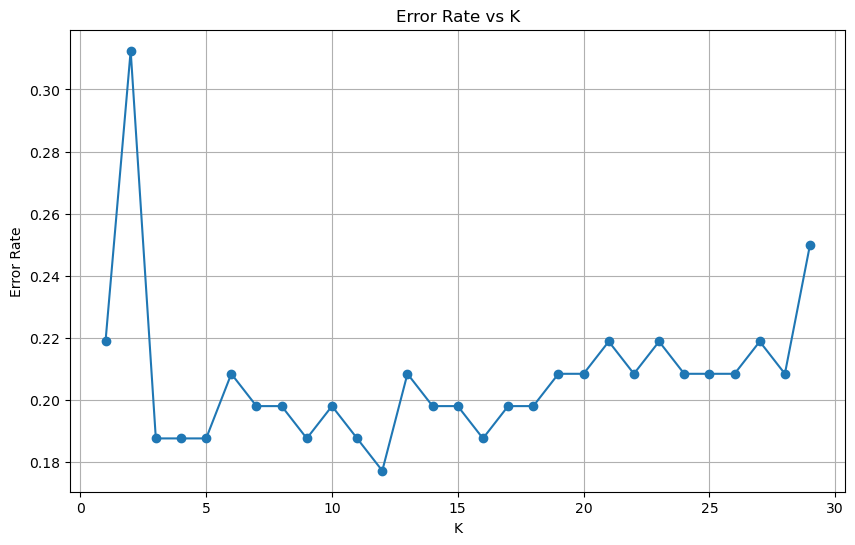

In [17]:
plt.figure(figsize=(10,6))
plt.plot(range(1,30), error_rate, marker='o')
plt.title('Error Rate vs K')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid()
plt.show()


In [18]:
knn = KNeighborsClassifier(n_neighbors=12)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


[[12 17]
 [ 0 67]]
              precision    recall  f1-score   support

           0       1.00      0.41      0.59        29
           1       0.80      1.00      0.89        67

    accuracy                           0.82        96
   macro avg       0.90      0.71      0.74        96
weighted avg       0.86      0.82      0.80        96



In [19]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree classification report:")
print(classification_report(y_test, y_pred_dt))

print("Decision Tree confusion matrix:")
print(confusion_matrix(y_test, y_pred_dt))


Decision Tree classification report:
              precision    recall  f1-score   support

           0       0.75      0.52      0.61        29
           1       0.82      0.93      0.87        67

    accuracy                           0.80        96
   macro avg       0.78      0.72      0.74        96
weighted avg       0.80      0.80      0.79        96

Decision Tree confusion matrix:
[[15 14]
 [ 5 62]]


In [20]:
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf']
}

svm = SVC()
svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)
print("Найкращі параметри SVM:", svm_grid.best_params_)


Найкращі параметри SVM: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


In [21]:
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

print("SVM classification report:")
print(classification_report(y_test, y_pred_svm))
print("SVM confusion matrix:")
print(confusion_matrix(y_test, y_pred_svm))


SVM classification report:
              precision    recall  f1-score   support

           0       1.00      0.41      0.59        29
           1       0.80      1.00      0.89        67

    accuracy                           0.82        96
   macro avg       0.90      0.71      0.74        96
weighted avg       0.86      0.82      0.80        96

SVM confusion matrix:
[[12 17]
 [ 0 67]]


In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest classification report:
              precision    recall  f1-score   support

           0       1.00      0.41      0.59        29
           1       0.80      1.00      0.89        67

    accuracy                           0.82        96
   macro avg       0.90      0.71      0.74        96
weighted avg       0.86      0.82      0.80        96

Random Forest confusion matrix:
[[12 17]
 [ 0 67]]


In [23]:
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("AdaBoost classification report:")
print(classification_report(y_test, y_pred_ada))
print("AdaBoost confusion matrix:")
print(confusion_matrix(y_test, y_pred_ada))


AdaBoost classification report:
              precision    recall  f1-score   support

           0       1.00      0.41      0.59        29
           1       0.80      1.00      0.89        67

    accuracy                           0.82        96
   macro avg       0.90      0.71      0.74        96
weighted avg       0.86      0.82      0.80        96

AdaBoost confusion matrix:
[[12 17]
 [ 0 67]]


In [24]:
# Створюємо словник для зберігання результатів
results_data = []

# Список ваших моделей та їхніх передбачень
models_list = [
    ("kNN", y_pred_knn),
    ("Decision Tree", y_pred_dt),
    ("SVM", y_pred_svm),
    ("Random Forest", y_pred_rf),
    ("AdaBoost", y_pred_ada)
]

for name, preds in models_list:
    report = classification_report(y_test, preds, output_dict=True)
    results_data.append({
        "Model": name,
        "Accuracy": report['accuracy'],
        "F1-score (Class 0)": report['0']['f1-score'],  # Відмови
        "F1-score (Class 1)": report['1']['f1-score'],  # Схвалення
        "Macro F1-avg": report['macro avg']['f1-score'] # Справедливе середнє
    })

# Створюємо DataFrame
results_df = pd.DataFrame(results_data).set_index("Model")

# Сортуємо за Macro F1, щоб побачити найбільш збалансовану модель
results_df = results_df.sort_values(by='Macro F1-avg', ascending=False)

print(results_df)

               Accuracy  F1-score (Class 0)  F1-score (Class 1)  Macro F1-avg
Model                                                                        
Decision Tree  0.802083            0.612245            0.867133      0.739689
kNN            0.822917            0.585366            0.887417      0.736392
SVM            0.822917            0.585366            0.887417      0.736392
Random Forest  0.822917            0.585366            0.887417      0.736392
AdaBoost       0.822917            0.585366            0.887417      0.736392
